# 2D Optimization Training with TensorBoard

This notebook demonstrates how to run the optimization loop using the `OptimizationTrainer` and visualize progress using TensorBoard directly within the notebook.

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch

import diffmeshopt.opt2d.sampling as sampling2d
import diffmeshopt.opt2d.vis as vis2d
from diffmeshopt.opt2d.optimize import BSplineContourRefiner, ContourRefiner
from diffmeshopt.opt2d.props import OptimizationProps, SamplingProps, TemplateProps
from diffmeshopt.opt2d.trainer import OptimizationTrainer, TrainerConfig


In [38]:
torch.set_float32_matmul_precision("medium")

In [39]:
# 1. Load Data
data_path = Path("/workspace/diffmeshopt/data/2d_training_data.pkl")
if not data_path.exists():
    print(f"Data file {data_path} not found. Please run src/generate_2d_data.py first.")
else:
    print(f"Loading data from {data_path}...")
    data = joblib.load(data_path)
    image_np = -data["image"]  # Invert intensity if needed based on previous notebooks
    contour_np = data["contour"]
    gt_contour_np = data["gt"]

Loading data from /workspace/diffmeshopt/data/2d_training_data.pkl...


In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [45]:
# 2. Setup Refiner
opt_props = OptimizationProps(
    lr=0.05,
    w_edge=0.5,
    w_laplacian=0.1,
    w_sigma_reg=0.0,
    w_template_shape=0.5,
    w_template_smooth=10,
)
sampl_props = SamplingProps(num_samples=51, sample_length=1.0)
template_props = TemplateProps(sigma=0.75, peak_dist=4.5, num_samples=51, min_peak_ratio=4)

refiner = BSplineContourRefiner(
    image=image_np,
    initial_contour=contour_np,
    optimization_props=opt_props,
    sampling_props=sampl_props,
    template_props=template_props,
    template_mode="global",
)

In [46]:
# 3. Setup Trainer

train_config = TrainerConfig(
    output_dir="/workspace/diffmeshopt/output/",
    image=image_np,
    gt_contour=contour_np,
    log_interval=10,
    log_image_interval=50,
    save_interval=50,
    use_tensorboard=True,
)

trainer = OptimizationTrainer(
    refiner=refiner,
    config=train_config,
)

trainer.reset_refiner()


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [47]:
# 5. Run Training
trainer.fit(steps_to_run=500)

/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /workspace/diffmeshopt/output/2026-01-27_22-45-27 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


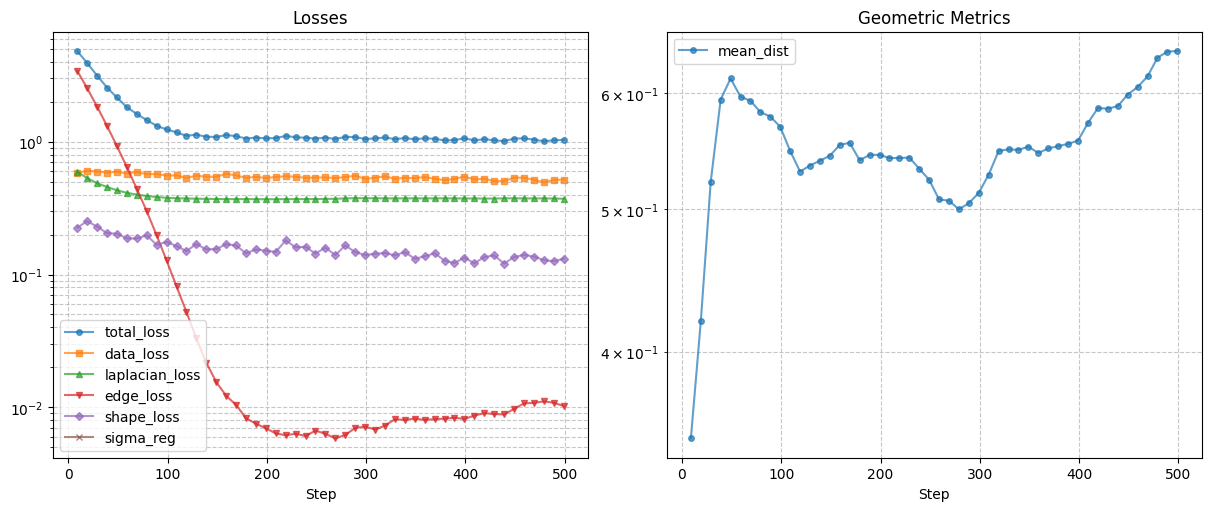

In [48]:
trainer.plot_metrics()

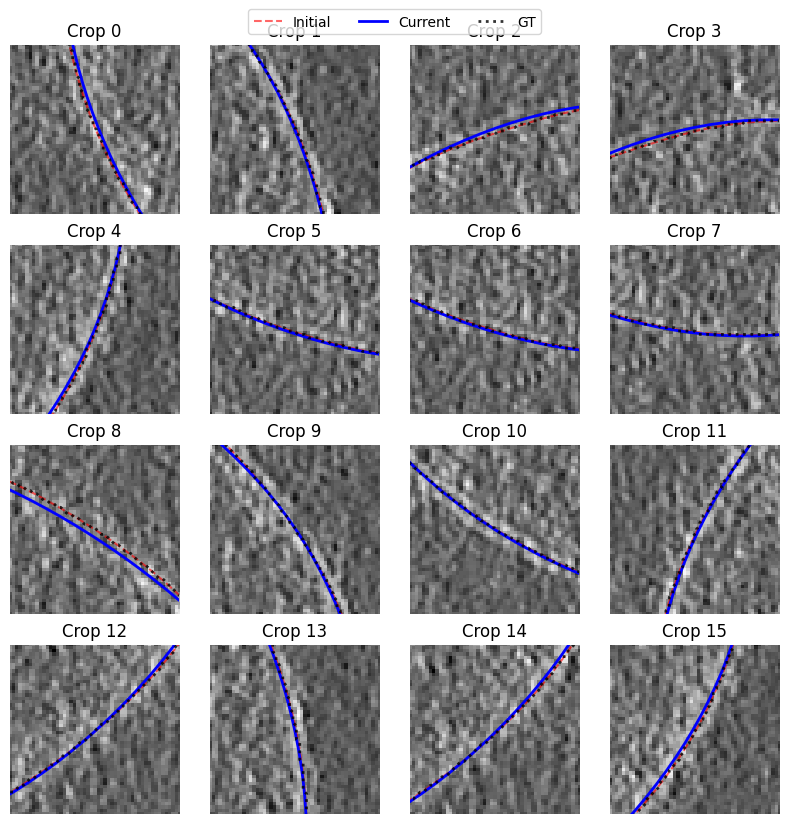

In [49]:
trainer.plot_image()

In [50]:
refiner.template_model.get_params()

{'peak_dist': tensor(3.7296, grad_fn=<MulBackward0>),
 'sigma': tensor(0.9273, grad_fn=<ExpBackward0>)}

In [51]:
template_params = refiner.template_model.get_params()

updated_template_props = template_props.model_copy(
    update={
        "peak_dist": template_params["peak_dist"].detach().cpu().numpy(),
        "sigma": template_params["sigma"].detach().cpu().numpy(),
    }
)
template_props, updated_template_props

(TemplateProps(peak_dist=4.5, sigma=0.75, amp=1.0, min_peak_ratio=4.0, num_samples=51, num_control_points=40, neural_hidden_dim=32, neural_num_layers=2),
 TemplateProps(peak_dist=array(3.7295659, dtype=float32), sigma=array(0.92730623, dtype=float32), amp=1.0, min_peak_ratio=4.0, num_samples=51, num_control_points=40, neural_hidden_dim=32, neural_num_layers=2))

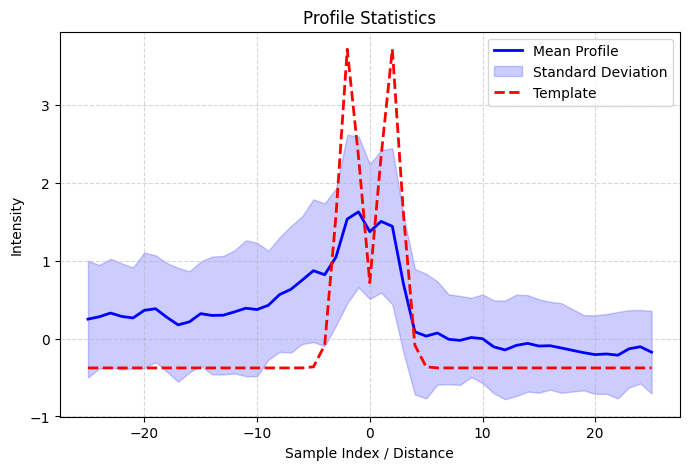

In [52]:
sample_profiles, _, _ = sampling2d.sample_profiles_stochastic(
    torch.from_numpy(image_np).float(),
    torch.from_numpy(contour_np).float(),
    sampling_props=sampl_props,
)

sample_profiles = sample_profiles.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 5))

vis2d.plot_profile_statistics(sample_profiles, ax=ax, template_props=updated_template_props)
plt.show()

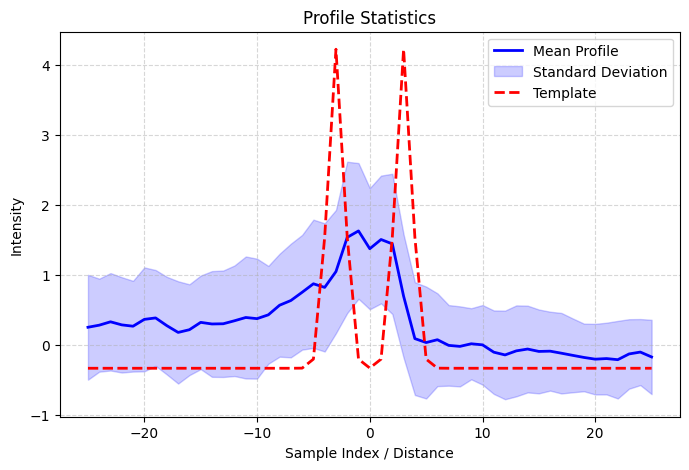

In [53]:
fig, ax = plt.subplots(figsize=(8, 5))

vis2d.plot_profile_statistics(sample_profiles, ax=ax)
plt.show()

## Trying out per-point optimization

In [55]:
# 2. Setup Refiner
opt_props = OptimizationProps(
    lr=0.05,
    w_edge=0.5,
    w_laplacian=0.1,
    w_sigma_reg=0.0,
    w_template_shape=0.5,
    w_template_smooth=10,
)
sampl_props = SamplingProps(num_samples=51, sample_length=1.0)
template_props = TemplateProps(sigma=0.75, peak_dist=4.5, num_samples=51, min_peak_ratio=4)

refiner = BSplineContourRefiner(
    image=image_np,
    initial_contour=contour_np,
    optimization_props=opt_props,
    sampling_props=sampl_props,
    template_props=template_props,
    template_mode="per_point",
)

In [56]:
# 3. Setup Trainer

train_config = TrainerConfig(
    output_dir="/workspace/diffmeshopt/output/",
    image=image_np,
    gt_contour=contour_np,
    log_interval=10,
    log_image_interval=50,
    save_interval=50,
    use_tensorboard=True,
)

trainer = OptimizationTrainer(
    refiner=refiner,
    config=train_config,
)

trainer.reset_refiner()


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [57]:
# 5. Run Training
trainer.fit(steps_to_run=500)

/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /workspace/diffmeshopt/output/2026-01-27_22-49-00 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 0:   0%| | 10/10000000 [00:00<48:17:44, 57.52it/s, v_num=.0_0, total_loss=

/workspace/diffmeshopt/diffmeshopt/opt2d/loss.py:219: UserWarning: Using a target size (torch.Size([100, 51])) that is different to the input size (torch.Size([51])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(mean_profile_norm, template)


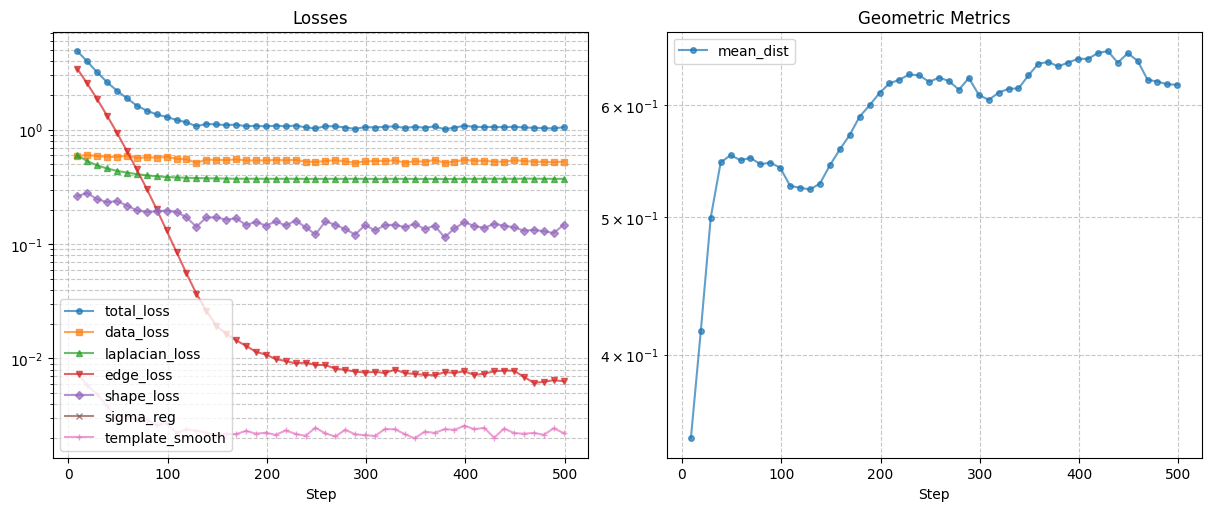

In [58]:
trainer.plot_metrics()

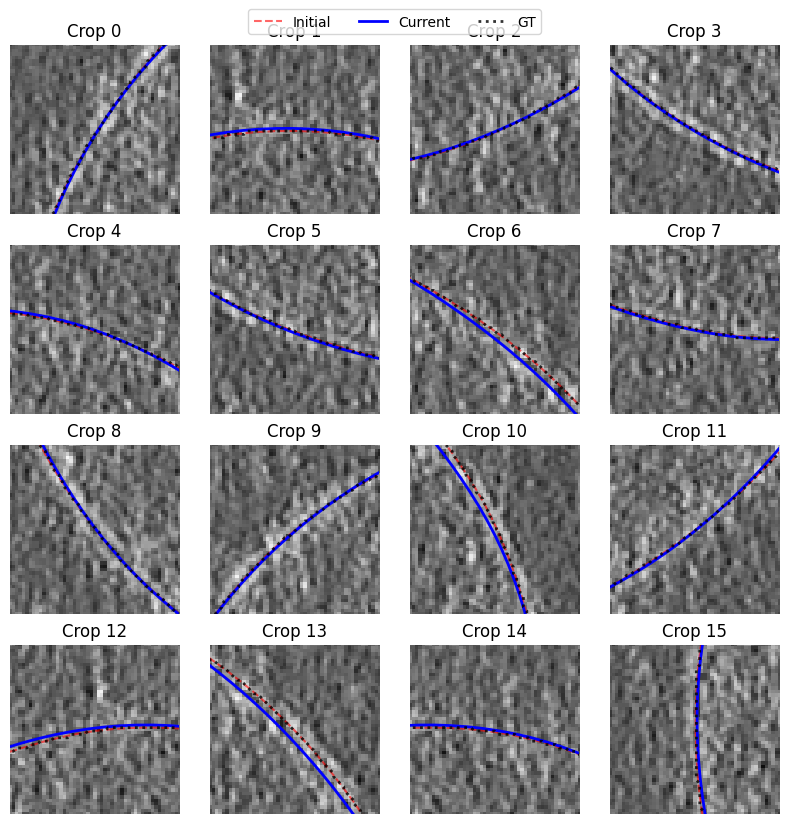

In [59]:
trainer.plot_image()

In [60]:
refiner.template_model.get_params()

{'peak_dist': tensor([3.5677, 3.5107, 3.5018, 3.5276, 3.5585, 3.5878, 3.6190, 3.5949, 3.5848,
         3.5964, 3.5573, 3.6249, 3.6338, 3.5942, 3.5978, 3.6396, 3.6006, 3.5365,
         3.5489, 3.5070, 3.5096, 3.5380, 3.5624, 3.5802, 3.5552, 3.5472, 3.5663,
         3.5985, 3.5950, 3.6602, 3.7016, 3.7251, 3.6662, 3.5806, 3.5381, 3.5847,
         3.6234, 3.6570, 3.6416, 3.6125, 3.6222, 3.6836, 3.6982, 3.7521, 3.8061,
         3.7420, 3.7211, 3.7048, 3.6970, 3.6993, 3.7024, 3.7058, 3.7019, 3.7728,
         3.8400, 3.8120, 3.7750, 3.7482, 3.7322, 3.6348, 3.6142, 3.5340, 3.4892,
         3.5138, 3.4904, 3.3894, 3.3461, 3.3552, 3.4053, 3.4623, 3.5070, 3.5430,
         3.5761, 3.5952, 3.6450, 3.7069, 3.6999, 3.7055, 3.7177, 3.7173, 3.6967,
         3.6762, 3.7243, 3.6780, 3.6094, 3.5725, 3.5624, 3.5079, 3.5441, 3.5713,
         3.5441, 3.5832, 3.5075, 3.5490, 3.5762, 3.5859, 3.6066, 3.6127, 3.6230,
         3.5949, 3.5801, 3.6217, 3.6835, 3.6716, 3.6861, 3.6812, 3.7401, 3.7824,
         3.8351

In [ ]:
template_params = refiner.template_model.get_params()

updated_template_props = template_props.model_copy(
    update={
        "peak_dist": template_params["peak_dist"].detach().cpu().numpy(),
        "sigma": template_params["sigma"].detach().cpu().numpy(),
    }
)
template_props, updated_template_props

(TemplateProps(peak_dist=4.5, sigma=0.75, amp=1.0, min_peak_ratio=4.0, num_samples=51, num_control_points=40, neural_hidden_dim=32, neural_num_layers=2),
 TemplateProps(peak_dist=array(3.7295659, dtype=float32), sigma=array(0.92730623, dtype=float32), amp=1.0, min_peak_ratio=4.0, num_samples=51, num_control_points=40, neural_hidden_dim=32, neural_num_layers=2))

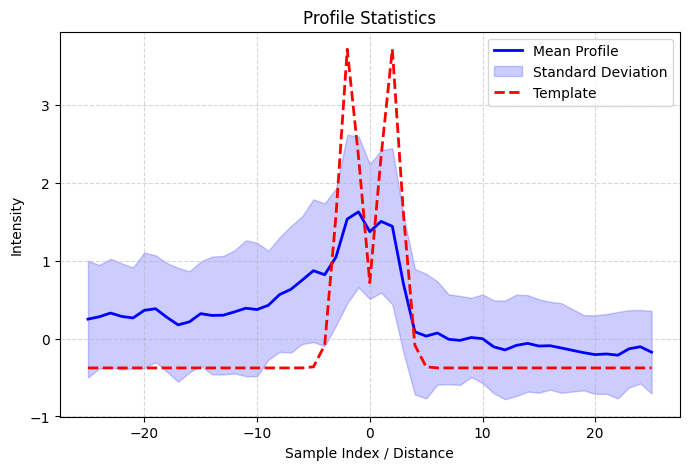

In [ ]:
sample_profiles, _, _ = sampling2d.sample_profiles_stochastic(
    torch.from_numpy(image_np).float(),
    torch.from_numpy(contour_np).float(),
    sampling_props=sampl_props,
)

sample_profiles = sample_profiles.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 5))

vis2d.plot_profile_statistics(sample_profiles, ax=ax, template_props=updated_template_props)
plt.show()

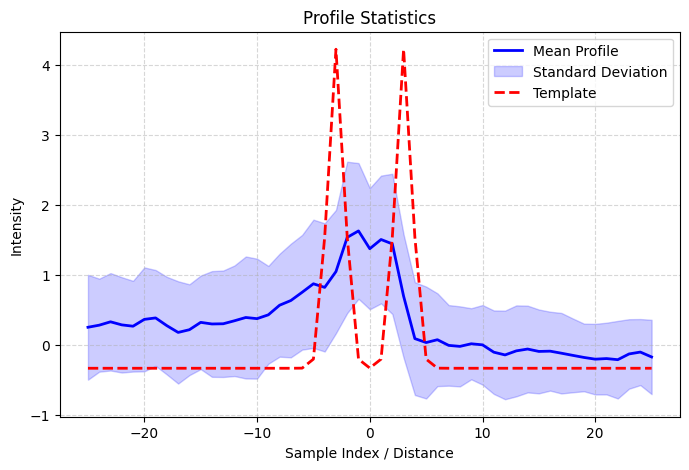

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

vis2d.plot_profile_statistics(sample_profiles, ax=ax)
plt.show()